# Single RocketPy simulation

Load a simulation-ready rocket JSON through `interpreter.py`, create a standard-atmosphere environment at the AEROPAC Black Rock Desert launch site, and run one RocketPy `Flight`.

The approximate launch-site waypoint is **40.870683° N, 119.106950° W**. AEROPAC notes that the exact pad position can change with playa conditions. The elevation is set to approximately **1,191 m above sea level**.

In [1]:
from __future__ import annotations

import json
import sys
from datetime import datetime, timedelta
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np

from rocketpy import Rocket

# Work whether Jupyter starts in the repository root or rocketpy/.
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "interpreter.py").is_file():
    PROJECT_DIR = PROJECT_DIR / "rocketpy"
if not (PROJECT_DIR / "interpreter.py").is_file():
    raise FileNotFoundError("Could not locate rocketpy/interpreter.py")

sys.path.insert(0, str(PROJECT_DIR))
from interpreter import RocketConfigurationError, load_rocket
from simrunner import run_single_simulation, runfullstacksim
from openmeteo_environment import create_openmeteo_environment

## Load a rocket JSON

Strict loading prevents a flight from starting with placeholder CDX1 values. Set `require_simulation_ready=False` only when inspecting geometry—not for a trusted simulation.

In [2]:
def load_rocket_json(
    json_path: str | Path,
    *,
    require_simulation_ready: bool = True,
) -> tuple[Rocket, dict[str, Any]]:
    """Load JSON data and construct its RocketPy Rocket."""
    path = Path(json_path)
    if not path.is_absolute():
        path = PROJECT_DIR / path
    path = path.resolve()

    with path.open(encoding="utf-8") as stream:
        configuration = json.load(stream)

    rocket = load_rocket(
        path,
        require_simulation_ready=require_simulation_ready,
    )
    return rocket, configuration

## Create the Black Rock Desert Open-Meteo environment

Call `create_openmeteo_environment` directly to fetch pressure, temperature, and wind profiles for Black Rock at the next local forecast hour.

In [3]:
BLACK_ROCK_LATITUDE = 40.870683
BLACK_ROCK_LONGITUDE = -119.106950
BLACK_ROCK_ELEVATION_M = 1191.0
BLACK_ROCK_TIMEZONE = "America/Los_Angeles"
OPENMETEO_MAX_HEIGHT_M = 80000.0

forecast_hour = datetime(2026, 9, 26, 12, 0, 0)
forecast_hour = forecast_hour.replace(minute=0, second=0, microsecond=0)
forecast_date = forecast_hour.strftime("%Y-%m-%d")
forecast_time = forecast_hour.strftime("%H:%M")

openmeteo_result = create_openmeteo_environment(
    latitude=BLACK_ROCK_LATITUDE,
    longitude=BLACK_ROCK_LONGITUDE,
    date=forecast_date,
    time=forecast_time,
    timezone_name=BLACK_ROCK_TIMEZONE,
    elevation_m=BLACK_ROCK_ELEVATION_M,
    endpoint="forecast",
    max_expected_height_m=OPENMETEO_MAX_HEIGHT_M,
)

print(f"Open-Meteo profile: {forecast_date} {forecast_time} {BLACK_ROCK_TIMEZONE}")
print(f"Model top before ISA extension: {openmeteo_result.model_top_height_m:.0f} m")

Open-Meteo profile: 2026-09-26 12:00 America/Los_Angeles
Model top before ISA extension: 31304 m


## Run one flight

Use the reusable `run_single_simulation` function imported from `simrunner.py`. Launch-rail settings can be supplied through its optional keyword arguments.

## Select the rocket and simulate

Change `JSON_PATH` to any completed `rocketpy-cdx1` JSON. The supplied `test.json` still contains CDX1 placeholders, so strict loading intentionally lists the motor, inertia, drag, rail-button, and recovery data that must be added before a meaningful flight can run.


Inertia Details

Rocket Mass: 3.299 kg (without motor)
Rocket Dry Mass: 5.567 kg (with unloaded motor)
Rocket Loaded Mass: 11.113 kg
Rocket Structural Mass Ratio: 0.501
Rocket Inertia (with unloaded motor) 11: 1.096 kg*m2
Rocket Inertia (with unloaded motor) 22: 1.096 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.004 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0377825 m
Rocket Frontal Area: 0.004485 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.033 m
Rocket Center of Dry Mass - Nozzle Exit: 0.680 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.048 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.024 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
BodyTube Fins Lift Coefficient Derivative: 8.737/rad

Center of Pre

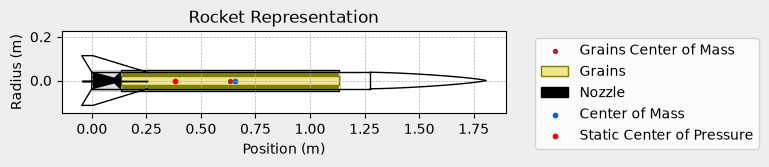


Mass Plots
----------------------------------------


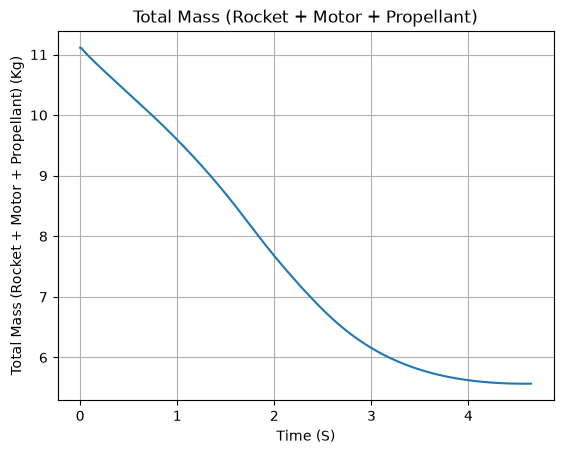

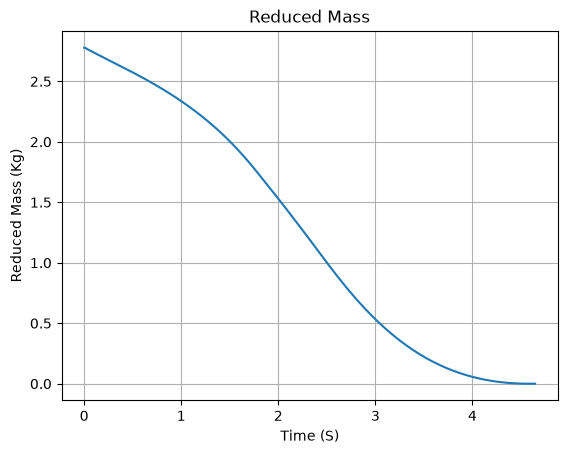


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


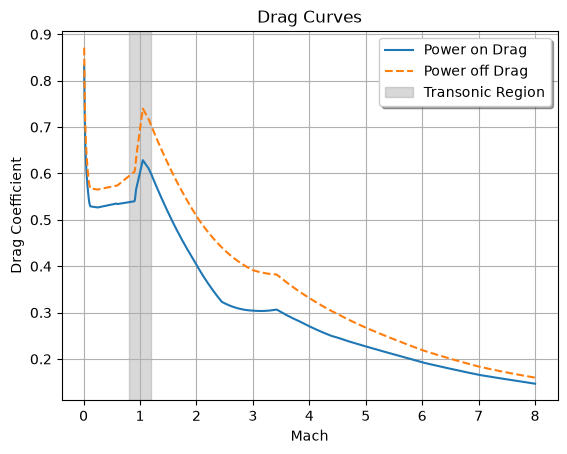


Stability Plots
--------------------


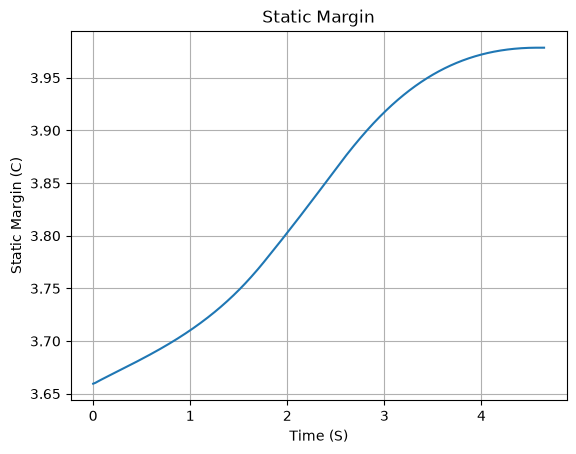

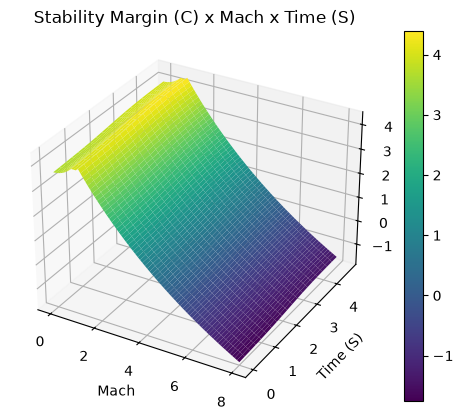


Thrust-to-Weight Plot
----------------------------------------


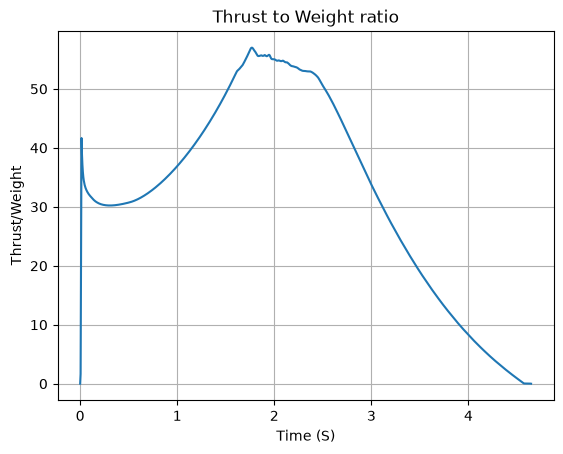

Nozzle Details
Nozzle Radius: 0.0377825755 m
Nozzle Throat Radius: 0.01 m

Grain Details
Number of Grains: 1
Grain Spacing: 0.0 m
Grain Density: 1799.1938061632031 kg/m3
Grain Outer Radius: 0.0377825755 m
Grain Inner Radius: 0.021128716695312064 m
Grain Height: 1.0001524 m
Grain Volume: 0.003 m3
Grain Mass: 5.546 kg

Motor Details
Total Burning Time: 4.6452 s
Total Propellant Mass: 5.546 kg
Structural Mass Ratio: 0.290
Average Propellant Exhaust Velocity: 2131.197 m/s
Average Thrust: 2544.642 N
Maximum Thrust: 4556.568 N at 0.0138 s after ignition.
Total Impulse: 11820.371 Ns



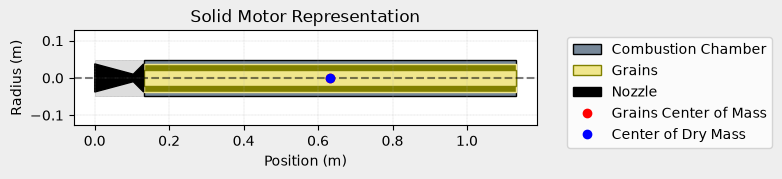

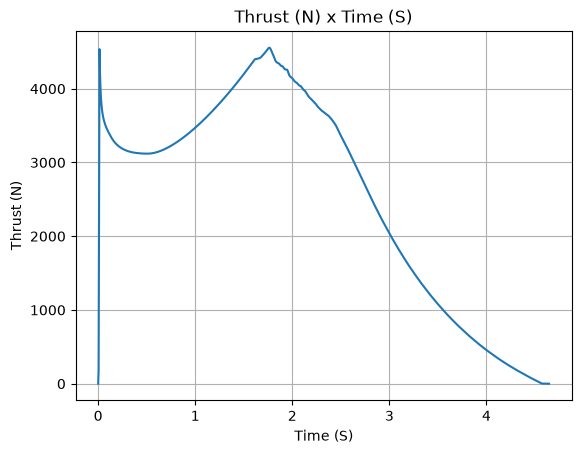

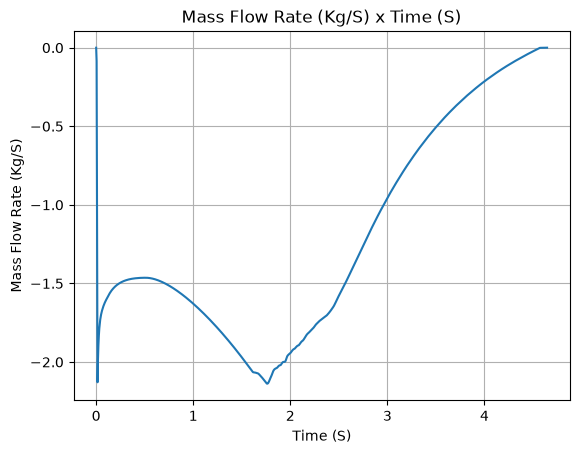

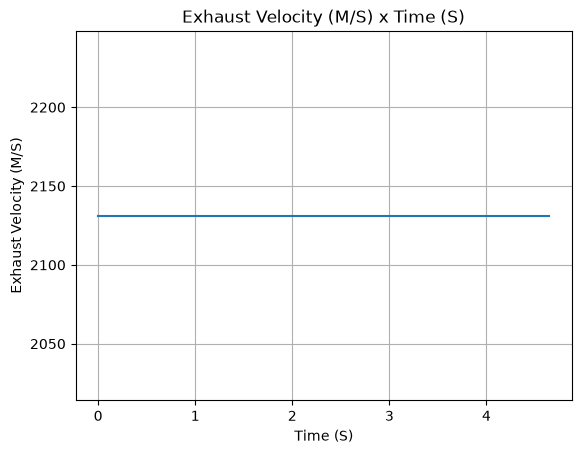

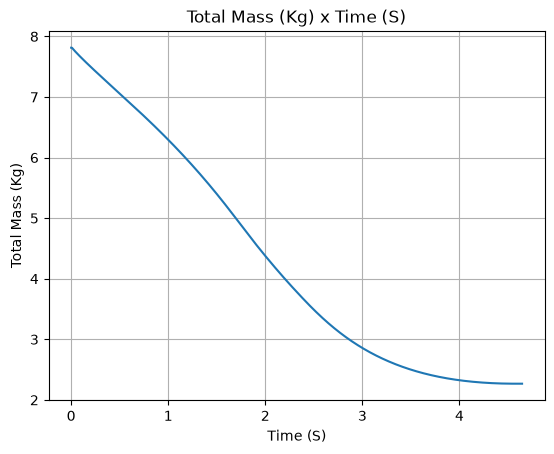

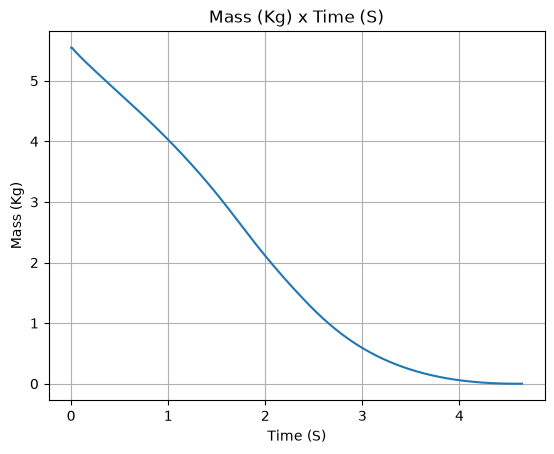

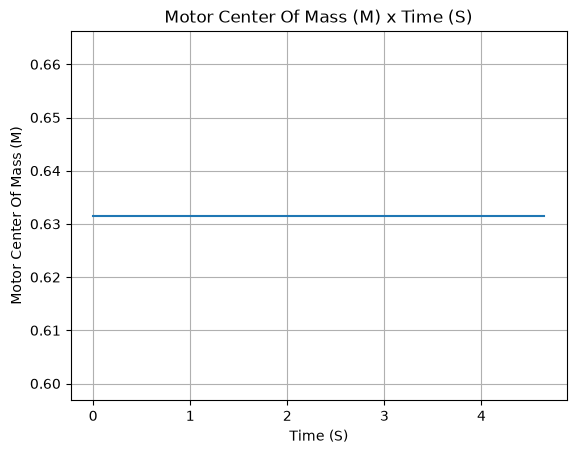

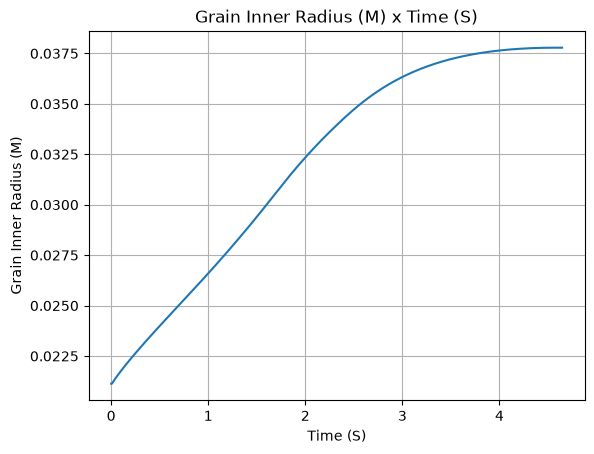

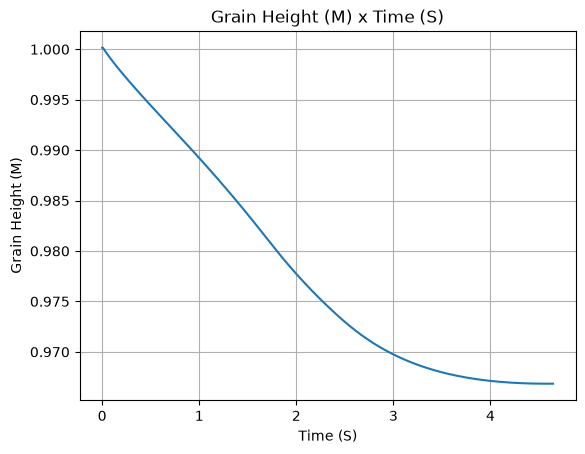

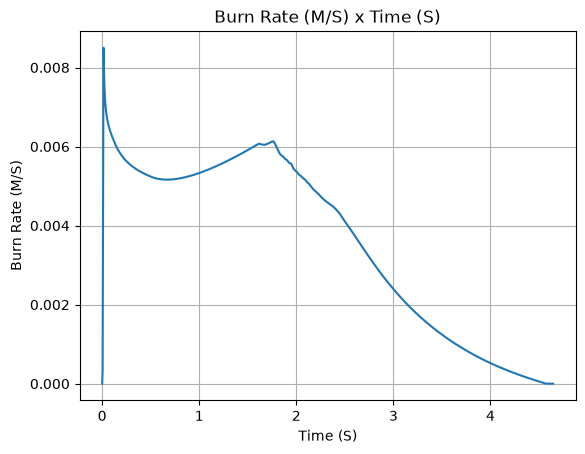

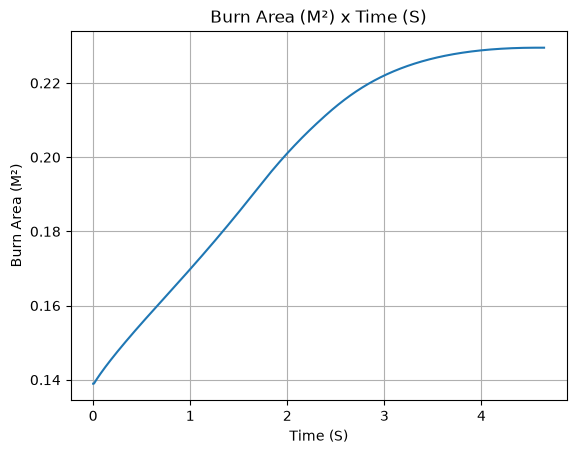

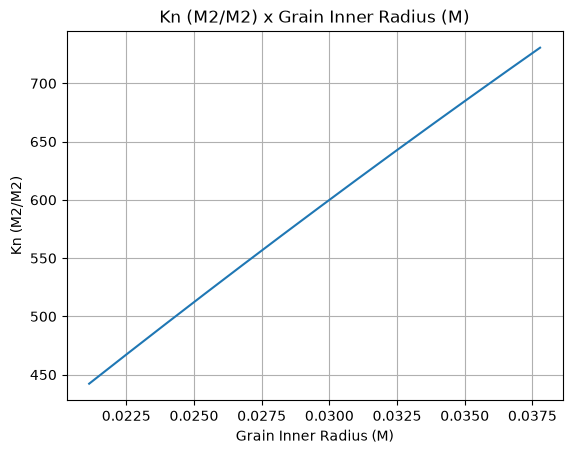

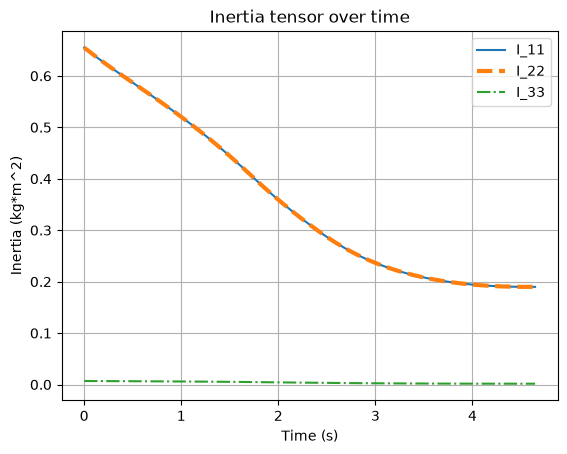

In [4]:
JSON_PATH = PROJECT_DIR / "./lijah simmy/ejarrocket.json"

rocket = load_rocket(
    JSON_PATH,
    require_simulation_ready=True,
)
rocket.all_info()

rocket.motor.all_info()
#rocket.motor.draw()

## Display all rocket information

RocketPy provides `all_info()` as the full rocket-information display call.

apogee was 61734.98529926857 ft

Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 1191.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 1.000 | e1: 0.000 | e2: 0.000 | e3: 0.000
Euler Angles - Spin φ : -180.00° | Nutation θ: 0.00° | Precession ψ: 180.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 3.660 c


Surface Wind Conditions

Frontal Surface Wind Speed: -1.96 m/s
Lateral Surface Wind Speed: 0.61 m/s


Launch Rail

Launch Rail Length: 5.2 m
Launch Rail Inclination: 90.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.189 s
Rail Departure Velocity: 55.859 m/s
Rail Departure Stability Margin: 3.681 c
Rail Departure Angle of Attack: 2.124°
Rail Departure Thrust-Weight Ratio: 30.614
Rail Departure Reynolds Number: 2.543e+05


Burn out State

Burn out time: 4.645 s
Altitude at burn out: 4647.718 m (ASL) | 3456.718 m (AGL)
Rocket speed at bu

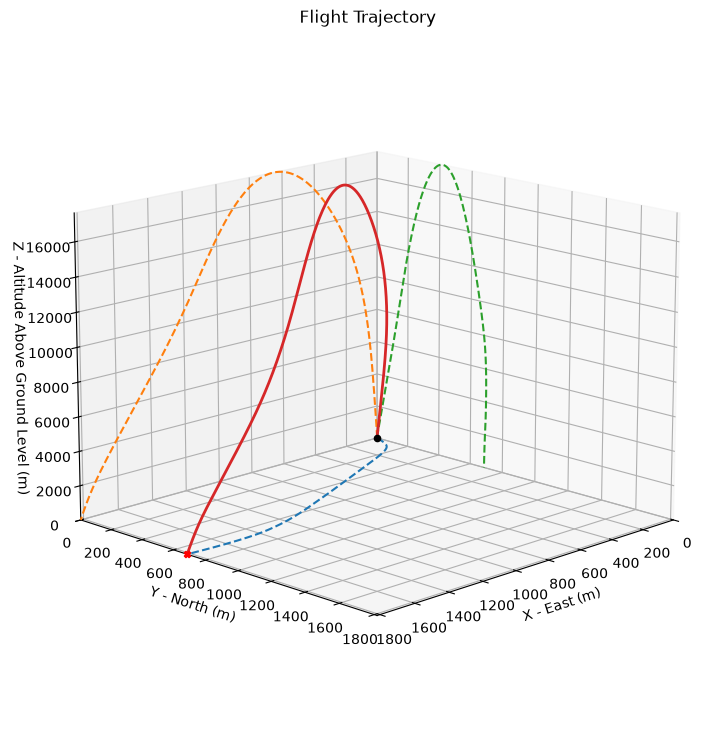

In [5]:


flight = run_single_simulation(rocket, openmeteo_result.environment,max_time_step=0.1)


print("apogee was " + str(flight.apogee * 3.281) + " ft")
flight.info()

flight.plots.trajectory_3d()

In [6]:
# Load both configurations from a version-2 JSON produced by cdx1tojson.py.
TWO_STAGE_JSON_PATH = PROJECT_DIR / ".\\builtjsons\\twostage.json"

full_stack_rocket = load_rocket(
    JSON_PATH,
    rocket_key="full_stack",
    require_simulation_ready=True,
)
sustainer_rocket = load_rocket(
    JSON_PATH,
    rocket_key="sustainer",
    require_simulation_ready=True,
)

full_stack_rocket.info()
full_stack_rocket.draw()
full_stack_rocket.motor.info()
full_stack_rocket.motor.draw()
sustainer_rocket.info()
sustainer_rocket.draw()
sustainer_rocket.motor.info()
sustainer_rocket.motor.draw()

RocketConfigurationError: rocket_key='full_stack' was supplied, but this file contains only one rocket

Sustainer ignition tilt: 2.53 degrees from vertical


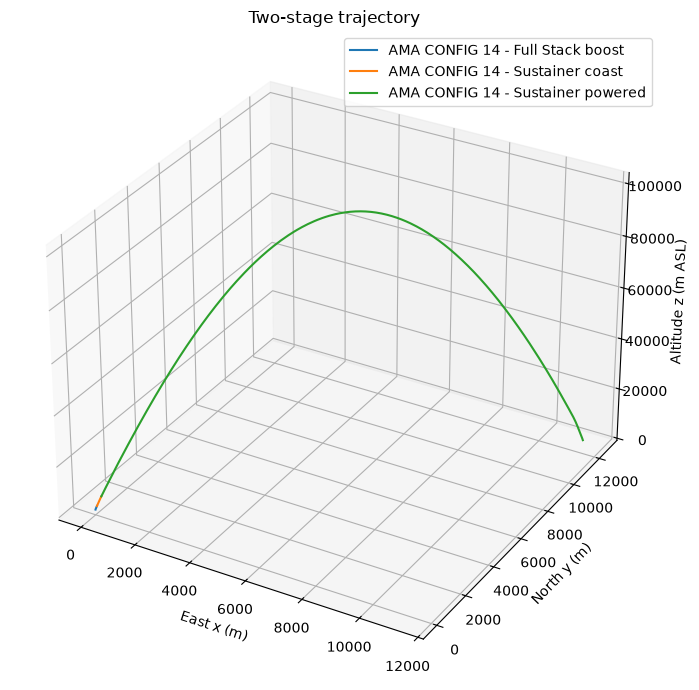

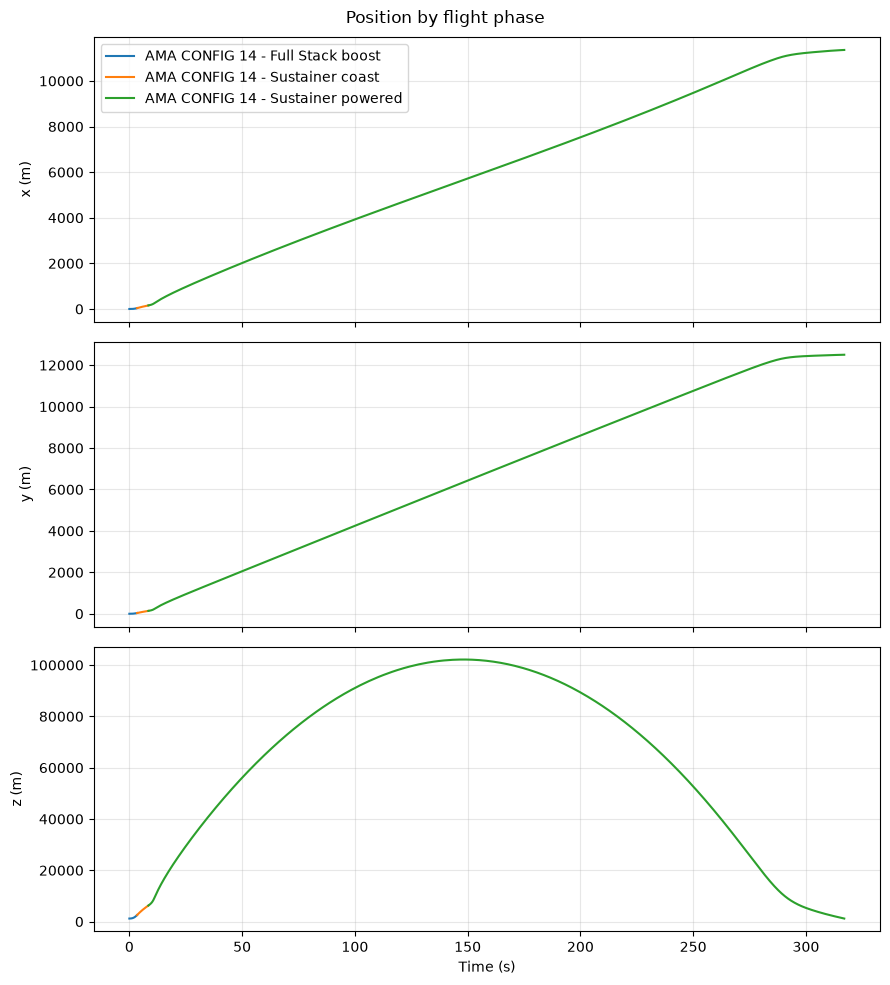

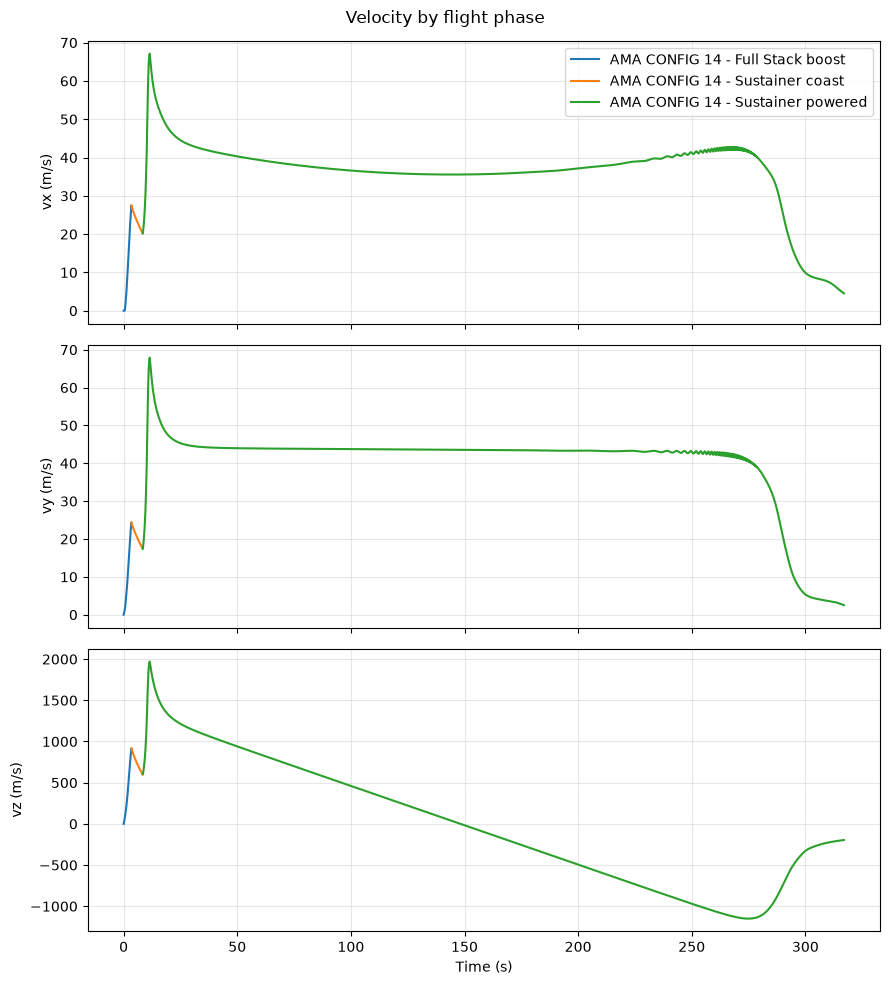

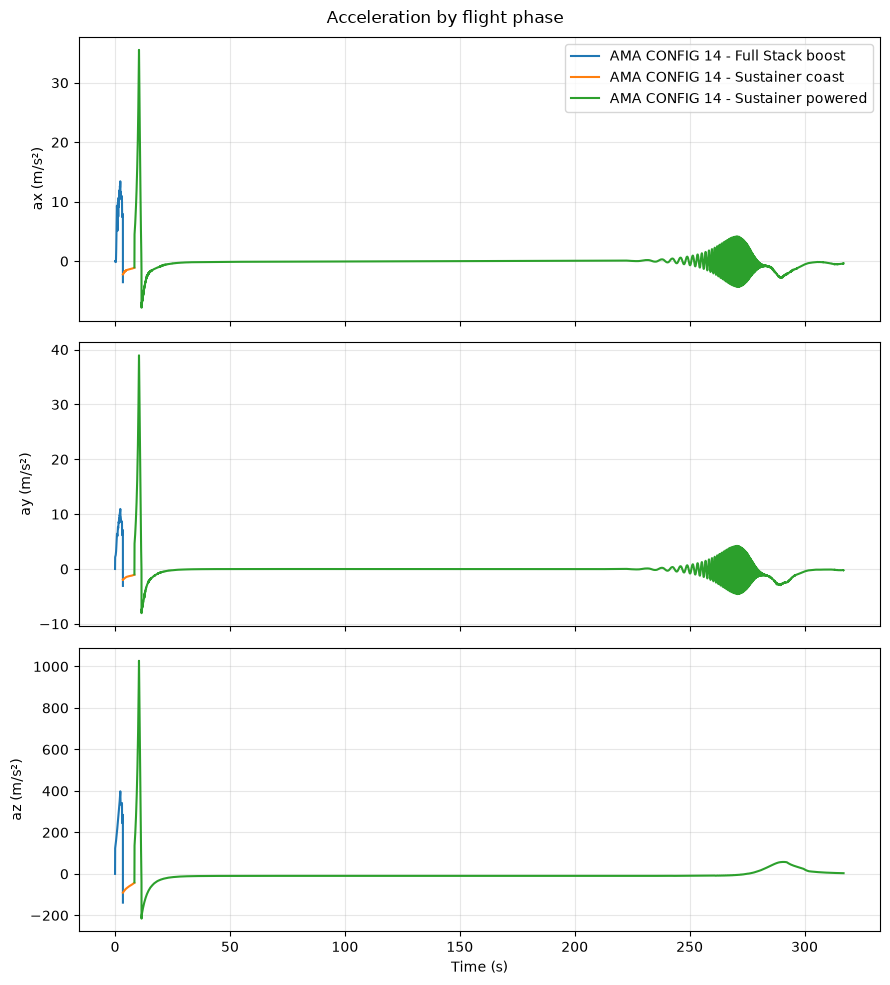

In [ ]:
COAST_PERIOD = 5.0  # Seconds from booster burnout to sustainer ignition.

two_stage_solution = runfullstacksim(
    full_stack_rocket,
    sustainer_rocket,
    openmeteo_result.environment,
    time_limit=600.0,
    coast_period=COAST_PERIOD,
    rail_length=6.0,
    rod_angle=1.0,
    heading=0.0,
)


def unique_phase_history(flight):
    """Return one phase history with strictly increasing timestamps."""
    states = np.asarray(flight.solution, dtype=float)
    if states.ndim != 2 or states.shape[1] < 7:
        raise ValueError(f"{flight.name} has an invalid RocketPy solution")
    finite_time = np.isfinite(states[:, 0])
    states = states[finite_time]
    _, first_indices = np.unique(states[:, 0], return_index=True)
    states = states[np.sort(first_indices)]
    if len(states) < 2 or np.any(np.diff(states[:, 0]) <= 0):
        raise ValueError(f"{flight.name} does not have enough unique time samples")
    return states


phase_histories = [
    (flight.name, unique_phase_history(flight))
    for flight in runfullstacksim.last_flights
]

fig = plt.figure(figsize=(9, 7))
axis_3d = fig.add_subplot(111, projection="3d")
for phase_name, states in phase_histories:
    axis_3d.plot(states[:, 1], states[:, 2], states[:, 3], label=phase_name)
axis_3d.set_xlabel("East x (m)")
axis_3d.set_ylabel("North y (m)")
axis_3d.set_zlabel("Altitude z (m ASL)")
axis_3d.set_title("Two-stage trajectory")
axis_3d.legend()
fig.tight_layout()
plt.show()


def plot_phase_components(title, values_by_phase, labels, units):
    fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
    for phase_name, time, values in values_by_phase:
        for component_index, axis in enumerate(axes):
            axis.plot(time, values[:, component_index], label=phase_name)
    for axis, label in zip(axes, labels):
        axis.set_ylabel(f"{label} ({units})")
        axis.grid(alpha=0.3)
    axes[-1].set_xlabel("Time (s)")
    axes[0].legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


position_series = [
    (phase_name, states[:, 0], states[:, 1:4])
    for phase_name, states in phase_histories
]
velocity_series = [
    (phase_name, states[:, 0], states[:, 4:7])
    for phase_name, states in phase_histories
]
acceleration_series = [
    (
        phase_name,
        states[:, 0],
        np.gradient(
            states[:, 4:7],
            states[:, 0],
            axis=0,
            edge_order=2 if len(states) > 2 else 1,
        ),
    )
    for phase_name, states in phase_histories
]

plot_phase_components("Position by flight phase", position_series, ("x", "y", "z"), "m")
plot_phase_components("Velocity by flight phase", velocity_series, ("vx", "vy", "vz"), "m/s")
plot_phase_components("Acceleration by flight phase", acceleration_series, ("ax", "ay", "az"), "m/s²")

